In [34]:
import argparse
from tqdm import tqdm

from scipy.io.wavfile import read
from librosa.util import normalize
import librosa
import numpy as np
import amfm_decompy.pYAAPT as pYAAPT
import amfm_decompy.basic_tools as basic

In [35]:
MAX_WAV_VALUE = 32768.0

parser = argparse.ArgumentParser(description="")
parser.add_argument("tsv", help="")
parser.add_argument("--extractor", choices=["crepe", "pyaapt"], default="pyaapt", help="")
parser.add_argument("--interp", action="store_true", help="")
parser.add_argument("--n_workers", type=int, default=40, help="")
# args = parser.parse_args()

_StoreAction(option_strings=['--n_workers'], dest='n_workers', nargs=None, const=None, default=40, type=<class 'int'>, choices=None, help='', metavar=None)

In [36]:
def extract_f0(wav_path,interp=False):

    # sr, wav = read(wav_path)
    # wav = wav / MAX_WAV_VALUE
    # wav = normalize(wav) * 0.95
    # print(wav.max(),wav.min())
    wav, sr = librosa.load(wav_path,sr=22050)

    frame_length = 20.0
    pad = int(frame_length / 1000 * sr) // 2
    wav = np.pad(wav.squeeze(), (pad, pad), "constant", constant_values=0)
    signal = basic.SignalObj(wav, sr)
    pitch = pYAAPT.yaapt(
            signal,
            **{
                'frame_length': frame_length,
                'frame_space': 5.0,
                'nccf_thresh1': 0.25,
                'tda_frame_length': 25.0
            })
    pitch = pitch.samp_interp[None, None, :] if interp else pitch.samp_values[None, None, :]
    pitch = pitch[0, 0]
    return pitch
    # f0_path = wav_path.replace(".wav", ".yaapt")
    # f0_path += ".interp.f0" if interp else ".f0"
    # np.save(f0_path, pitch)

In [7]:
import matplotlib.pyplot as plt

def plot_curve(y_values,figsize=(10,2)):
    x_values = range(len(y_values))
    plt.figure(figsize=figsize) 
    plt.plot(x_values, y_values, label='Curve') 
    plt.xlabel('time')
    plt.ylabel('f0')
    plt.title('Curve Plot')
    plt.show()

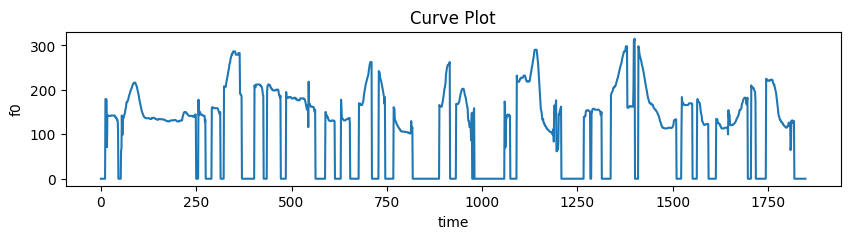

In [46]:
# plot_curve(p0)
# sr, wav = read(wav_path)
# wav = wav / MAX_WAV_VALUE
# wav = normalize(wav) * 0.95

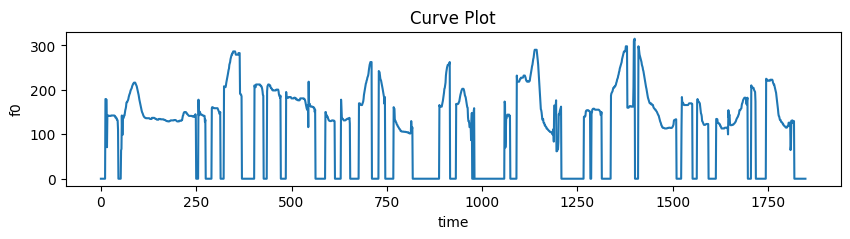

In [38]:
p0=extract_f0('6415_111615_000012_000005.wav')
plot_curve(p0)

In [48]:
# type(p0),p0.shape

(numpy.ndarray, (1849,))

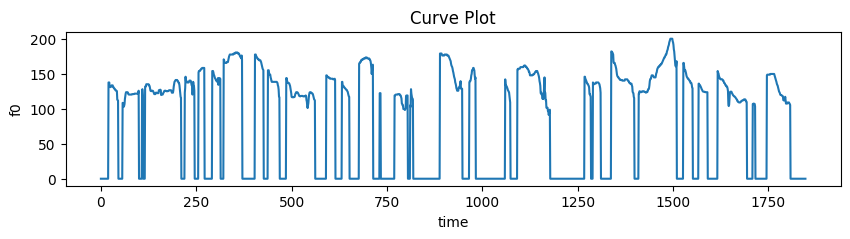

In [39]:
p1=extract_f0('baseline.wav')
plot_curve(p1)

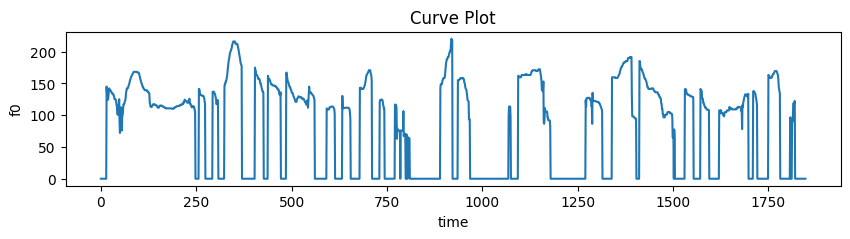

In [40]:
p2=extract_f0('diffvc+.wav')
plot_curve(p2)

In [41]:
p0.mean(),p0.max(),  p1.mean(),p1.max(),  p2.mean(),p2.max()

(113.08412788008098,
 315.0,
 83.4668524146598,
 200.45454545454547,
 80.02896897176471,
 220.5)

In [42]:
read('0001_000001.wav')[1].max()

31330

In [44]:
import librosa
librosa.load('0001_000001.wav')[0].min(),librosa.load('0001_000001.wav')[0].max()

(-0.84902877, 0.96351683)

In [8]:
import matplotlib.pyplot as plt

def plot_curves(y_values1, y_values2, y_values3, figsize=(10, 2)):
    t=min(len(y_values1),len(y_values2),len(y_values3))
    
    x_values = range(t)
    
    plt.figure(figsize=figsize)
    plt.plot(x_values, y_values1[:t], label='Curve 1', color='blue')
    plt.plot(x_values, y_values2[:t], label='Curve 2', color='green')
    plt.plot(x_values, y_values3[:t], label='Curve 3', color='red')

    plt.xlabel('time')
    plt.ylabel('f0')
    plt.title('Multiple Curves Plot')
    plt.legend()
    plt.show()

In [46]:
len(p0),len(p1),len(p2)

(1849, 1848, 1848)

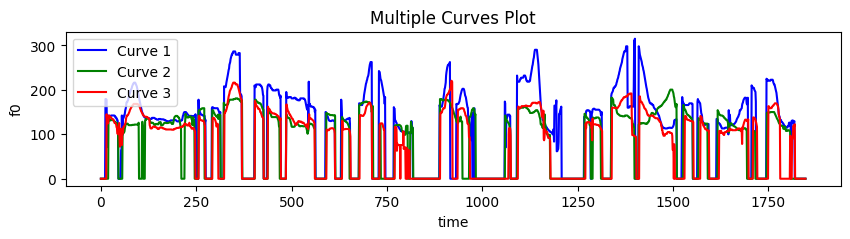

In [47]:
plot_curves(p0,p1,p2)

In [48]:
import numpy as np
correlation1 = np.corrcoef(p0[:1848], p1)[0, 1]
correlation2 = np.corrcoef(p0[:1848], p2)[0, 1]
correlation12 = np.corrcoef(p1, p2)[0, 1]
correlation1, correlation2, correlation12

(0.7386863261394657, 0.8078824454780041, 0.7220600941815476)

In [9]:
import numpy as np

def normalize_curve(y_values):  
    min_value = y_values.min()
    max_value = y_values.max()
    normalized_curve = (y_values - min_value) / (max_value - min_value)
    return normalized_curve

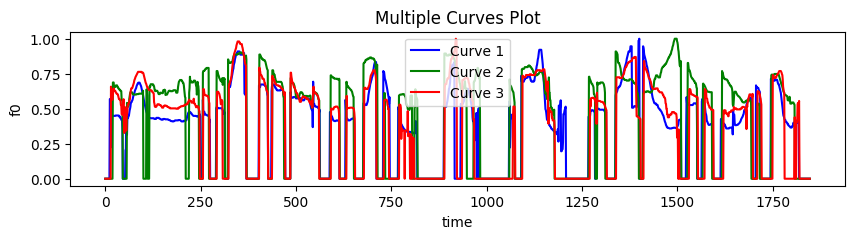

In [50]:
plot_curves(normalize_curve(p0),normalize_curve(p1),normalize_curve(p2))

In [51]:
import numpy as np
correlation1 = np.corrcoef(normalize_curve(p0)[:1848], normalize_curve(p1))[0, 1]
correlation2 = np.corrcoef(normalize_curve(p0)[:1848], normalize_curve(p2))[0, 1]
correlation12 = np.corrcoef(normalize_curve(p1), normalize_curve(p2))[0, 1]
correlation1, correlation2, correlation12

(0.7386863261394673, 0.8078824454780053, 0.7220600941815494)

In [1]:
import sys
sys.path.append('../speaker_encoder/')
from encoder import inference as spk_encoder
def get_embed(wav_path):
    wav_preprocessed = spk_encoder.preprocess_wav(wav_path)
    embed = spk_encoder.embed_utterance(wav_preprocessed)
    return embed

In [2]:
from pathlib import Path
enc_model_fpath = Path('../checkpts/spk_encoder/pretrained.pt') # speaker encoder path
spk_encoder.load_model(enc_model_fpath, device="cuda")

Loaded encoder "pretrained.pt" trained to step 1564501


In [3]:
e0=get_embed('6415_111615_000012_000005.wav')
e1=get_embed('baseline.wav')
e2=get_embed('diffvc+.wav')

In [4]:
type(e0),e0.shape

(numpy.ndarray, (256,))

In [7]:
import numpy as np
def cosine_similarity(vector1, vector2):
    dot_product = np.dot(vector1, vector2)
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)
    
    similarity = dot_product / (norm_vector1 * norm_vector2)
    
    return similarity

In [8]:
cosine_similarity(e0,e1),cosine_similarity(e0,e2),cosine_similarity(e1,e2)

(0.69586086, 0.67416024, 0.8690164)

In [2]:
import torchcrepe

In [3]:
audio,sr0 = torchcrepe.load.audio('6415_111615_000012_000005.wav')
sr0,audio.shape

(24000, torch.Size([1, 221280]))

In [4]:
import librosa
wav, sr = librosa.load('6415_111615_000012_000005.wav',sr=22050)

In [5]:
import torch
hop_length = int(22050 / 200.)

fmin = 50
fmax = 550

model = 'tiny'

device = 'cuda:0'

# Pick a batch size that doesn't cause memory errors on your gpu
batch_size = 2048

# Compute pitch using first gpu
pitch = torchcrepe.predict(torch.from_numpy(wav).unsqueeze(0).cuda(),
                           sr,
                           hop_length,
                           fmin,
                           fmax,
                           model,
                           batch_size=batch_size,
                           device=device)
pp0=pitch.detach().cpu().squeeze().numpy()

In [5]:
pitch.shape

torch.Size([1, 1868])

In [80]:
embeddings = torchcrepe.embed(torch.from_numpy(wav).unsqueeze(0).cuda(), sr, hop_length)

In [81]:
embeddings.shape

torch.Size([1, 1868, 32, 64])

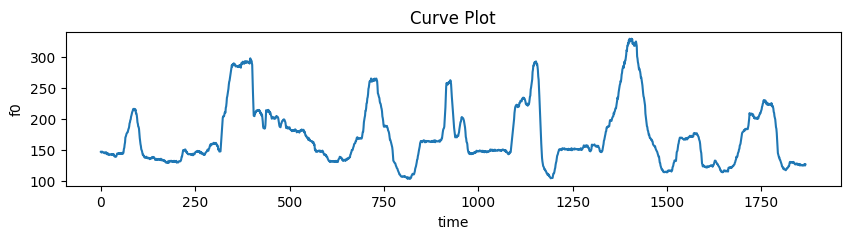

In [10]:
plot_curve(pitch.detach().cpu().squeeze().numpy())

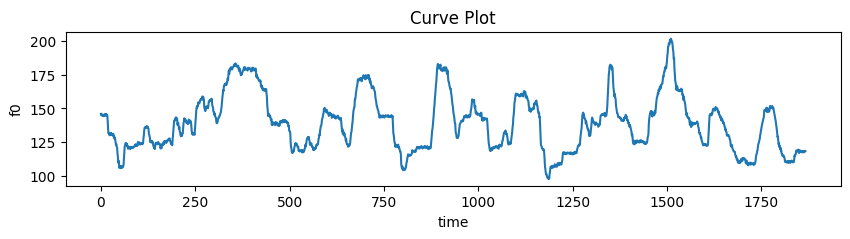

In [11]:
wav1, sr = librosa.load('baseline.wav',sr=22050)
pitch1 = torchcrepe.predict(torch.from_numpy(wav1).unsqueeze(0).cuda(),
                           sr,
                           hop_length,
                           fmin,
                           fmax,
                           model,
                           batch_size=batch_size,
                           device=device)
pp1=pitch1.detach().cpu().squeeze().numpy()
plot_curve(pitch1.detach().cpu().squeeze().numpy())

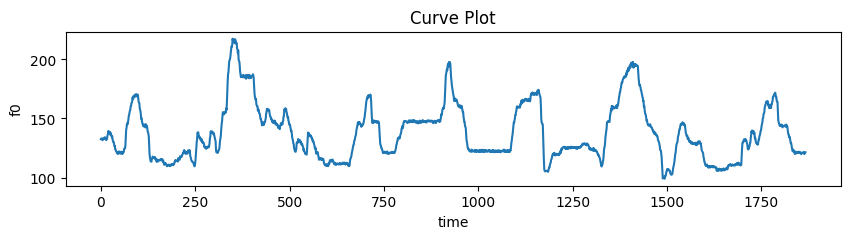

In [12]:
wav2, sr = librosa.load('diffvc+.wav',sr=22050)
pitch2 = torchcrepe.predict(torch.from_numpy(wav2).unsqueeze(0).cuda(),
                           sr,
                           hop_length,
                           fmin,
                           fmax,
                           model,
                           batch_size=batch_size,
                           device=device)
pp2=pitch2.detach().cpu().squeeze().numpy()
plot_curve(pitch2.detach().cpu().squeeze().numpy())

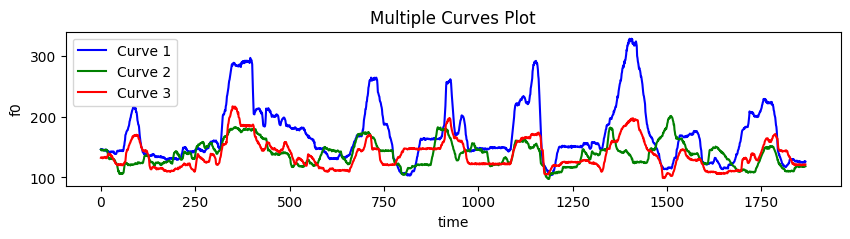

In [13]:
plot_curves(pp0,pp1,pp2)

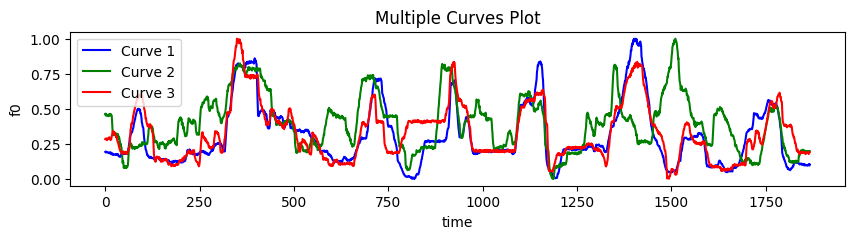

In [14]:
plot_curves(normalize_curve(pp0),normalize_curve(pp1),normalize_curve(pp2))

In [23]:
import numpy as np
correlation1 = np.corrcoef(pp0, pp1)[0, 1]
correlation2 = np.corrcoef(pp0, pp2)[0, 1]
correlation12 = np.corrcoef(pp1, pp2)[0, 1]
correlation1, correlation2, correlation12

(0.4065920929563342, 0.8481592188761282, 0.38130727996982966)

In [53]:
np.linspace(0,10-1,10)

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [12]:
from shapesimilarity import shape_similarity

In [20]:
from shapesimilarity import shape_similarity
import matplotlib.pyplot as plt
import numpy as np

def plot_shape_sim(y1, y2):
    t=min(len(y1),len(y2))
    x = np.linspace(1, t-1, num=t)


    shape1 = np.column_stack((x, y1[:t]+1))
    shape2 = np.column_stack((x, y2[:t]+1))

    similarity = shape_similarity(shape1, shape2)
    plt.figure(figsize=(10,2))
    plt.plot(shape1[:,0], shape1[:,1], linewidth=2.0)
    plt.plot(shape2[:,0], shape2[:,1], linewidth=2.0)

    plt.title(f'Shape similarity is: {similarity}', fontsize=14, fontweight='bold')
    plt.show()

###############
0.0
###############


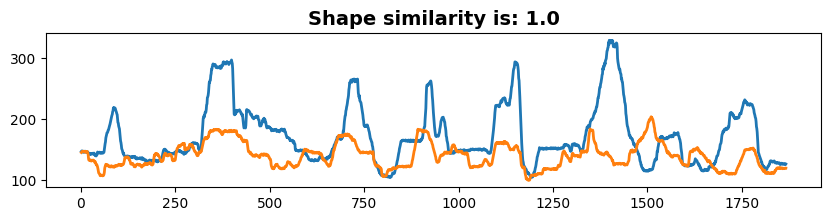

In [21]:
plot_shape_sim(pp0,pp1)

###############
0.0
###############


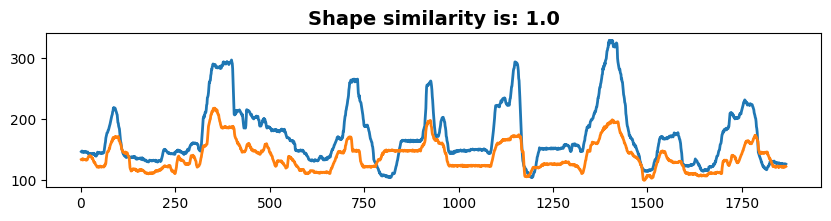

In [17]:
plot_shape_sim(pp0,pp2)

###############
5.849538443330364
###############


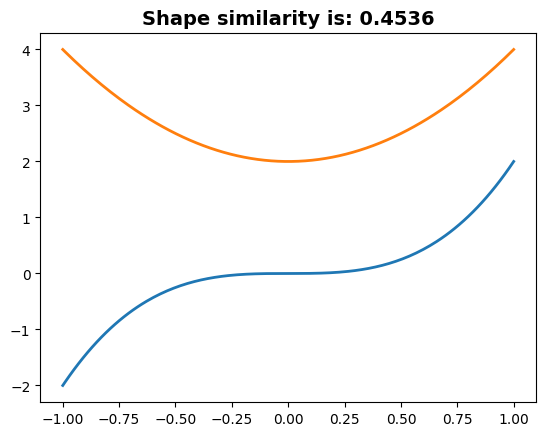

In [15]:
from shapesimilarity import shape_similarity
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(1, -1, num=200)

y1 = 2*x**3 
y2 = 2*x**2 + 2

shape1 = np.column_stack((x, y1))
shape2 = np.column_stack((x, y2))

similarity = shape_similarity(shape1, shape2)

plt.plot(shape1[:,0], shape1[:,1], linewidth=2.0)
plt.plot(shape2[:,0], shape2[:,1], linewidth=2.0)

plt.title(f'Shape similarity is: {similarity}', fontsize=14, fontweight='bold')
plt.show()

In [16]:
import numpy as np

def _c(ca, i, j, p, q):

    if ca[i, j] > -1:
        return ca[i, j]
    elif i == 0 and j == 0:
        ca[i, j] = np.linalg.norm(p[i]-q[j])
    elif i > 0 and j == 0:
        ca[i, j] = max(_c(ca, i-1, 0, p, q), np.linalg.norm(p[i]-q[j]))
    elif i == 0 and j > 0:
        ca[i, j] = max(_c(ca, 0, j-1, p, q), np.linalg.norm(p[i]-q[j]))
    elif i > 0 and j > 0:
        ca[i, j] = max(
            min(
                _c(ca, i-1, j, p, q),
                _c(ca, i-1, j-1, p, q),
                _c(ca, i, j-1, p, q)
            ),
            np.linalg.norm(p[i]-q[j])
            )
    else:
        ca[i, j] = float('inf')

    return ca[i, j]

def frdist(p, q):
    """
    >>> from frechetdist import frdist
    >>> P=[[1,1], [2,1], [2,2]]
    >>> Q=[[2,2], [0,1], [2,4]]
    >>> frdist(P,Q)
    """
    p = np.array(p, np.float64)
    q = np.array(q, np.float64)

    len_p = len(p)
    len_q = len(q)

    if len_p == 0 or len_q == 0:
        raise ValueError('Input curves are empty.')

    if len_p != len_q or len(p[0]) != len(q[0]):
        raise ValueError('Input curves do not have the same dimensions.')

    ca = (np.ones((len_p, len_q), dtype=np.float64) * -1)

    dist = _c(ca, len_p-1, len_q-1, p, q)
    return dist

def cal_frdist(y1, y2):
    t=min(len(y1),len(y2))
    x = np.linspace(1, t-1, num=t)

    shape1 = np.column_stack((x, y1[:t]+1))
    shape2 = np.column_stack((x, y2[:t]+1))

    return frdist(shape1, shape2)

In [18]:
cal_frdist(pp0[:500],pp1[:500])

117.48902225994023

In [20]:
cal_frdist(normalize_curve(pp0[500:]),normalize_curve(pp1[500:]))

0.9420757293701172

In [21]:
cal_frdist(normalize_curve(pp0[500:]),normalize_curve(pp2[500:]))

0.4952104091644287

In [22]:
cal_frdist(normalize_curve(pp1[500:]),normalize_curve(pp2[500:]))

0.9610121250152588

In [23]:
usdict={'p252': [('p252_002', 'p252'), ('p252_001', 'p252'), ('p252_003', 'p252'), ('p252_005', 'p252'), ('p252_004', 'p252')], 'p261': [('p261_001', 'p261'), ('p261_005', 'p261'), ('p261_002', 'p261'), ('p261_003', 'p261'), ('p261_004', 'p261')], 'p241': [('p241_003', 'p241'), ('p241_005', 'p241'), ('p241_001', 'p241'), ('p241_004', 'p241'), ('p241_002', 'p241')], 'p238': [('p238_003', 'p238'), ('p238_004', 'p238'), ('p238_005', 'p238'), ('p238_002', 'p238'), ('p238_001', 'p238')], 'p243': [('p243_003', 'p243'), ('p243_002', 'p243'), ('p243_005', 'p243'), ('p243_001', 'p243'), ('p243_004', 'p243')], 'p294': [('p294_002', 'p294'), ('p294_003', 'p294'), ('p294_001', 'p294'), ('p294_005', 'p294'), ('p294_004', 'p294')], 'p334': [('p334_002', 'p334'), ('p334_001', 'p334'), ('p334_005', 'p334'), ('p334_003', 'p334'), ('p334_004', 'p334')], 'p343': [('p343_003', 'p343'), ('p343_001', 'p343'), ('p343_004', 'p343'), ('p343_002', 'p343'), ('p343_005', 'p343')], 'p360': [('p360_004', 'p360'), ('p360_001', 'p360'), ('p360_003', 'p360'), ('p360_005', 'p360'), ('p360_002', 'p360')], 'p362': [('p362_005', 'p362'), ('p362_003', 'p362'), ('p362_002', 'p362'), ('p362_004', 'p362'), ('p362_001', 'p362')]}
usdict

{'p252': [('p252_002', 'p252'),
  ('p252_001', 'p252'),
  ('p252_003', 'p252'),
  ('p252_005', 'p252'),
  ('p252_004', 'p252')],
 'p261': [('p261_001', 'p261'),
  ('p261_005', 'p261'),
  ('p261_002', 'p261'),
  ('p261_003', 'p261'),
  ('p261_004', 'p261')],
 'p241': [('p241_003', 'p241'),
  ('p241_005', 'p241'),
  ('p241_001', 'p241'),
  ('p241_004', 'p241'),
  ('p241_002', 'p241')],
 'p238': [('p238_003', 'p238'),
  ('p238_004', 'p238'),
  ('p238_005', 'p238'),
  ('p238_002', 'p238'),
  ('p238_001', 'p238')],
 'p243': [('p243_003', 'p243'),
  ('p243_002', 'p243'),
  ('p243_005', 'p243'),
  ('p243_001', 'p243'),
  ('p243_004', 'p243')],
 'p294': [('p294_002', 'p294'),
  ('p294_003', 'p294'),
  ('p294_001', 'p294'),
  ('p294_005', 'p294'),
  ('p294_004', 'p294')],
 'p334': [('p334_002', 'p334'),
  ('p334_001', 'p334'),
  ('p334_005', 'p334'),
  ('p334_003', 'p334'),
  ('p334_004', 'p334')],
 'p343': [('p343_003', 'p343'),
  ('p343_001', 'p343'),
  ('p343_004', 'p343'),
  ('p343_002', 'p

In [25]:
d={}
d['a']=(1,2)
d

{'a': (1, 2)}

In [1]:
a=['a','s','d']
a

['a', 's', 'd']